# scikit-learn Binary Classification ML Pipeline

A comprehensive, reusable ML pipeline for **binary classification** tasks.  
Covers **EDA → preprocessing → feature engineering → model training (13 algorithms) → hyperparameter tuning → evaluation → statistical analysis**.

> **How to adapt to your own dataset:**  
> 1. Replace the data-loading block in Section 1 with `pd.read_csv("your_file.csv")`.  
> 2. Set `TARGET_COL` to the name of your binary target column.  
> 3. Run all cells top-to-bottom.

**Algorithms covered**  
| # | Algorithm | Family |
|---|-----------|--------|
| 1 | Logistic Regression | Linear |
| 2 | Decision Tree | Tree |
| 3 | Random Forest | Ensemble (Bagging) |
| 4 | Extra Trees | Ensemble (Bagging) |
| 5 | Bagging Classifier | Ensemble (Bagging) |
| 6 | Gradient Boosting | Ensemble (Boosting) |
| 7 | AdaBoost | Ensemble (Boosting) |
| 8 | XGBoost | Ensemble (Boosting) |
| 9 | LightGBM | Ensemble (Boosting) |
| 10 | Support Vector Machine | Kernel |
| 11 | K-Nearest Neighbours | Instance-based |
| 12 | Gaussian Naive Bayes | Probabilistic |
| 13 | MLP Neural Network | Neural Network |

## 0. Imports & Configuration

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from itertools import combinations

# ── sklearn ──────────────────────────────────────────────────────────────────
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score,
    RandomizedSearchCV, cross_validate,
)
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.decomposition import PCA
from sklearn.inspection import permutation_importance

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
    AdaBoostClassifier, ExtraTreesClassifier, BaggingClassifier,
)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report,
    confusion_matrix, roc_curve, auc, ConfusionMatrixDisplay,
)

# ── Third-party boosting libraries ───────────────────────────────────────────
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ── Global plot style ─────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="tab10", font_scale=1.1)
plt.rcParams.update({"figure.dpi": 110, "figure.figsize": (10, 6)})

# ── Reproducibility ───────────────────────────────────────────────────────────
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("All libraries loaded successfully.")


All libraries loaded successfully.


## 1. Data Loading

> Replace the block below with `pd.read_csv("your_file.csv")` and set `TARGET_COL` accordingly.

In [2]:
# ── Load built-in breast-cancer dataset (replace with your own CSV) ──────────
data = load_breast_cancer(as_frame=True)
df = data.frame.copy()
TARGET_COL = "target"          # 0 = malignant, 1 = benign

# For a CSV file use:
# df = pd.read_csv("your_data.csv")
# TARGET_COL = "your_target_column"

print(f"Dataset shape : {df.shape}")
print(f"Target column : '{TARGET_COL}'")
print(f"Class counts  :\n{df[TARGET_COL].value_counts()}")
df.head()


Dataset shape : (569, 31)
Target column : 'target'
Class counts  :
target
1    357
0    212
Name: count, dtype: int64


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


## 2. Exploratory Data Analysis (EDA)

In [3]:
# ── 2.1 Basic info ───────────────────────────────────────────────────────────
print("=== DataFrame Info ===")
df.info()
print("\n=== Missing values ===")
print(df.isnull().sum()[df.isnull().sum() > 0].to_string() or "None")


=== DataFrame Info ===
<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness err

In [4]:
# ── 2.2 Descriptive statistics ──────────────────────────────────────────────
df.describe().T.style.background_gradient(cmap="Blues", subset=["mean", "std"])


,count,mean,std,min,25%,50%,75%,max
mean radius,569.000000,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.110000
mean texture,569.000000,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.280000
mean perimeter,569.000000,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.500000
mean area,569.000000,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.000000
mean smoothness,569.000000,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.163400
mean compactness,569.000000,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.345400
mean concavity,569.000000,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.426800
mean concave points,569.000000,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.201200
mean symmetry,569.000000,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.304000
mean fractal dimension,569.000000,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.097440


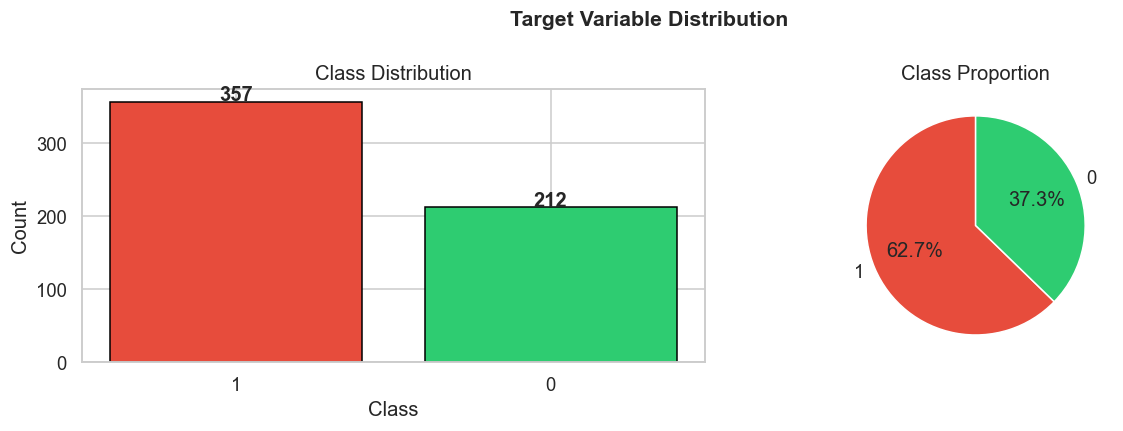

Imbalance ratio (min/max): 0.594
✓  Classes are reasonably balanced.


In [5]:
# ── 2.3 Class distribution ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

class_counts = df[TARGET_COL].value_counts()
axes[0].bar(class_counts.index.astype(str), class_counts.values,
            color=["#e74c3c", "#2ecc71"], edgecolor="black")
axes[0].set_title("Class Distribution")
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Count")
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 1, str(v), ha="center", fontweight="bold")

axes[1].pie(class_counts.values, labels=class_counts.index.astype(str),
            autopct="%1.1f%%", startangle=90,
            colors=["#e74c3c", "#2ecc71"])
axes[1].set_title("Class Proportion")

plt.suptitle("Target Variable Distribution", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

imbalance_ratio = class_counts.min() / class_counts.max()
print(f"Imbalance ratio (min/max): {imbalance_ratio:.3f}")
if imbalance_ratio < 0.5:
    print("⚠  Moderate-to-severe class imbalance detected. Consider resampling or class_weight='balanced'.")
else:
    print("✓  Classes are reasonably balanced.")


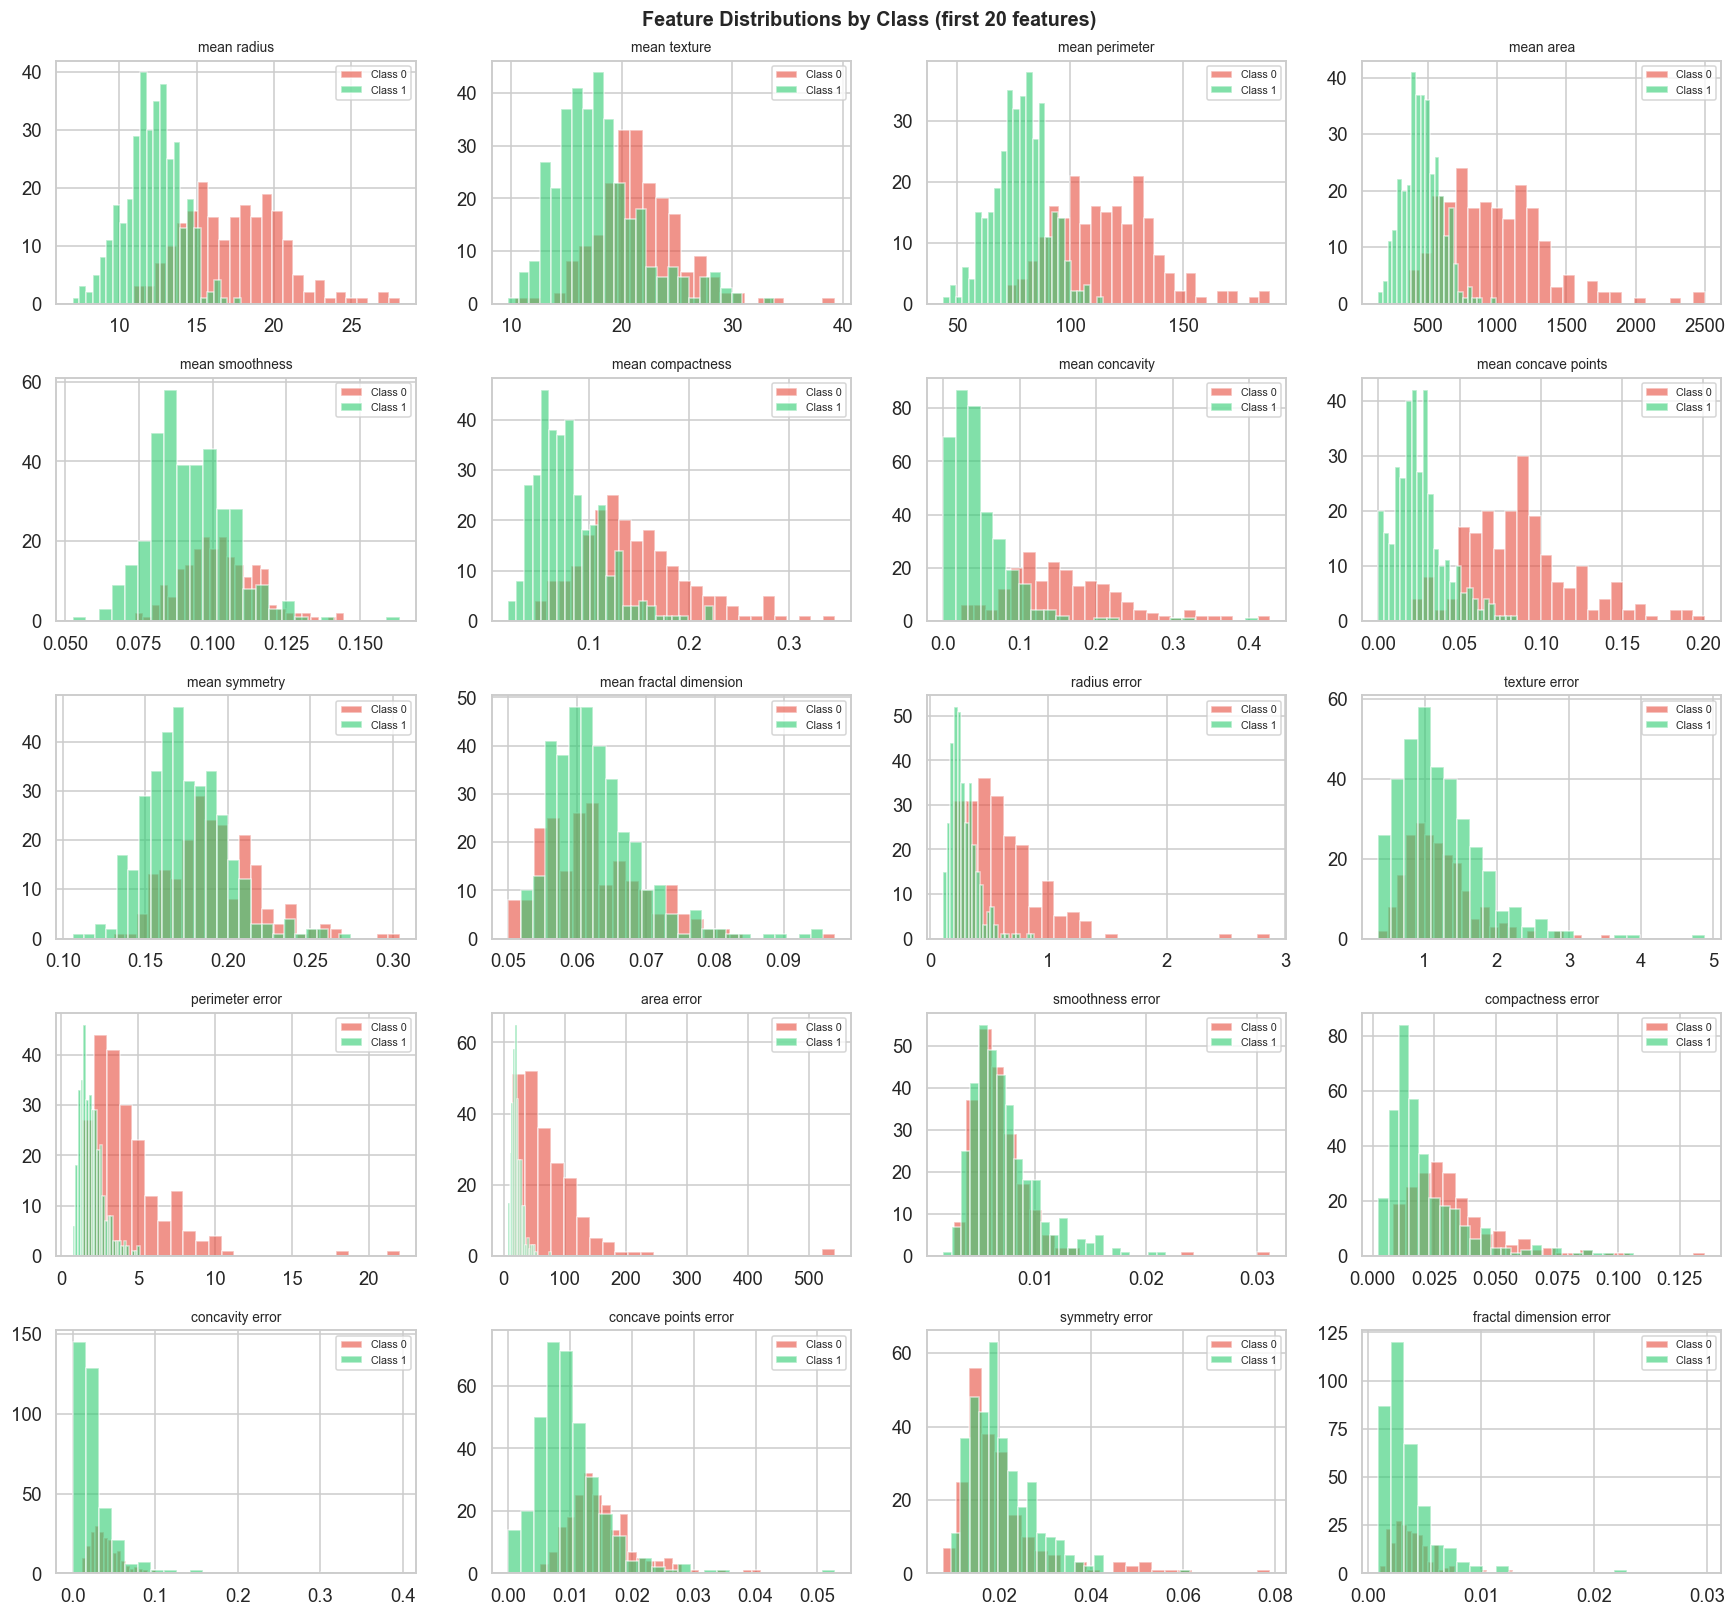

In [6]:
# ── 2.4 Feature distributions ────────────────────────────────────────────────
feature_cols = [c for c in df.columns if c != TARGET_COL]
numeric_cols = df[feature_cols].select_dtypes(include=[np.number]).columns.tolist()

# Plot histograms for first 20 numeric features
plot_cols = numeric_cols[:20]
n_cols = 4
n_rows = int(np.ceil(len(plot_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(plot_cols):
    for label, colour in zip(df[TARGET_COL].unique(), ["#e74c3c", "#2ecc71"]):
        axes[i].hist(df.loc[df[TARGET_COL] == label, col],
                     bins=25, alpha=0.6, label=f"Class {label}", color=colour)
    axes[i].set_title(col, fontsize=9)
    axes[i].legend(fontsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Feature Distributions by Class (first 20 features)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


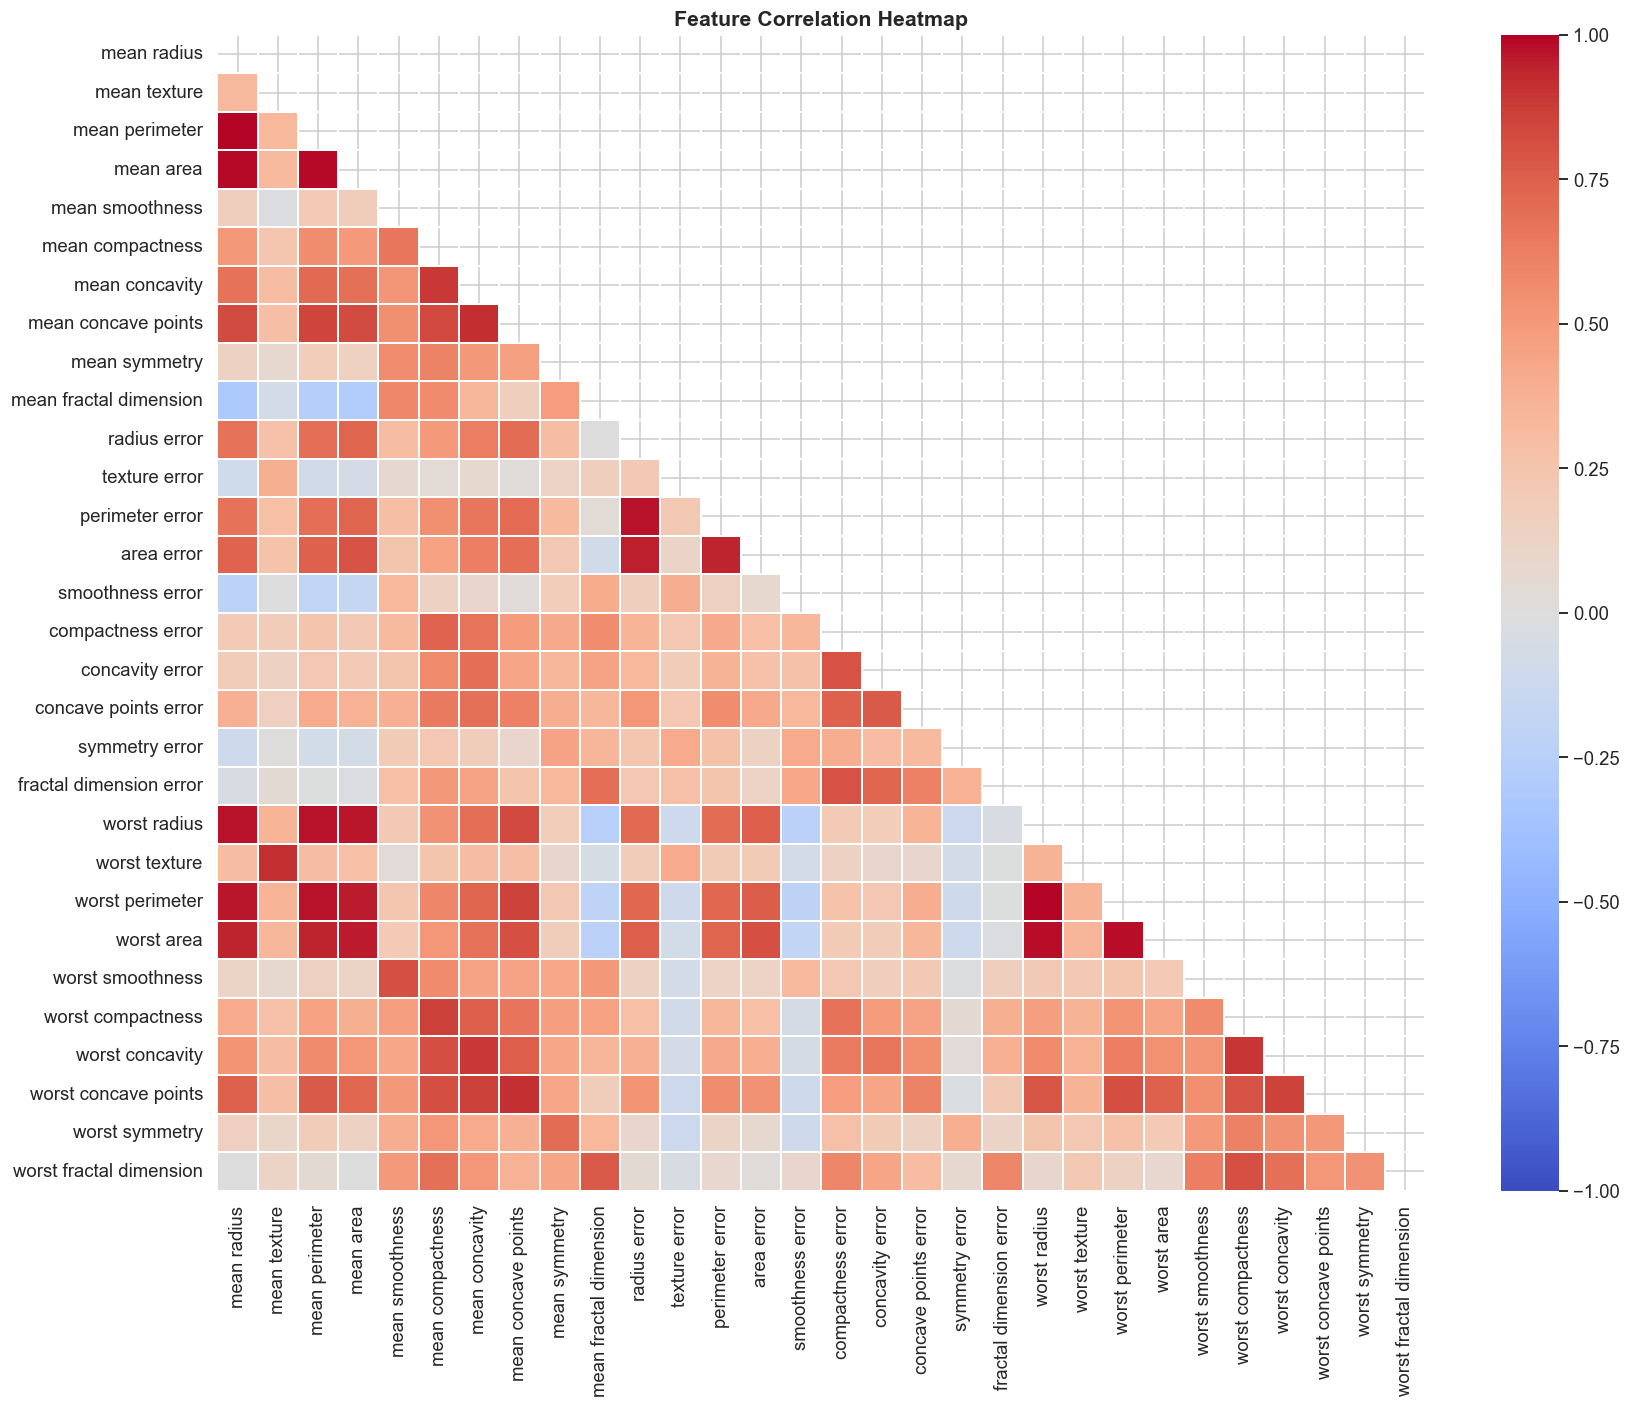

Top 10 most correlated feature pairs:
      Feature A       Feature B  Correlation
 mean perimeter     mean radius     0.997855
worst perimeter    worst radius     0.993708
      mean area     mean radius     0.987357
      mean area  mean perimeter     0.986507
     worst area    worst radius     0.984015
     worst area worst perimeter     0.977578
perimeter error    radius error     0.972794
worst perimeter  mean perimeter     0.970387
   worst radius     mean radius     0.969539
   worst radius  mean perimeter     0.969476


In [7]:
# ── 2.5 Correlation heatmap ──────────────────────────────────────────────────
corr = df[numeric_cols].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))
plt.figure(figsize=(16, 13))
sns.heatmap(corr, mask=mask, cmap="coolwarm", center=0,
            annot=False, linewidths=0.3, vmin=-1, vmax=1)
plt.title("Feature Correlation Heatmap", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# Top correlated pairs
corr_pairs = (
    corr.where(mask == False)
        .stack()
        .reset_index()
        .rename(columns={"level_0": "Feature A", "level_1": "Feature B", 0: "Correlation"})
)
corr_pairs = corr_pairs[corr_pairs["Feature A"] != corr_pairs["Feature B"]]
corr_pairs["abs_corr"] = corr_pairs["Correlation"].abs()
print("Top 10 most correlated feature pairs:")
print(corr_pairs.nlargest(10, "abs_corr")[["Feature A", "Feature B", "Correlation"]].to_string(index=False))


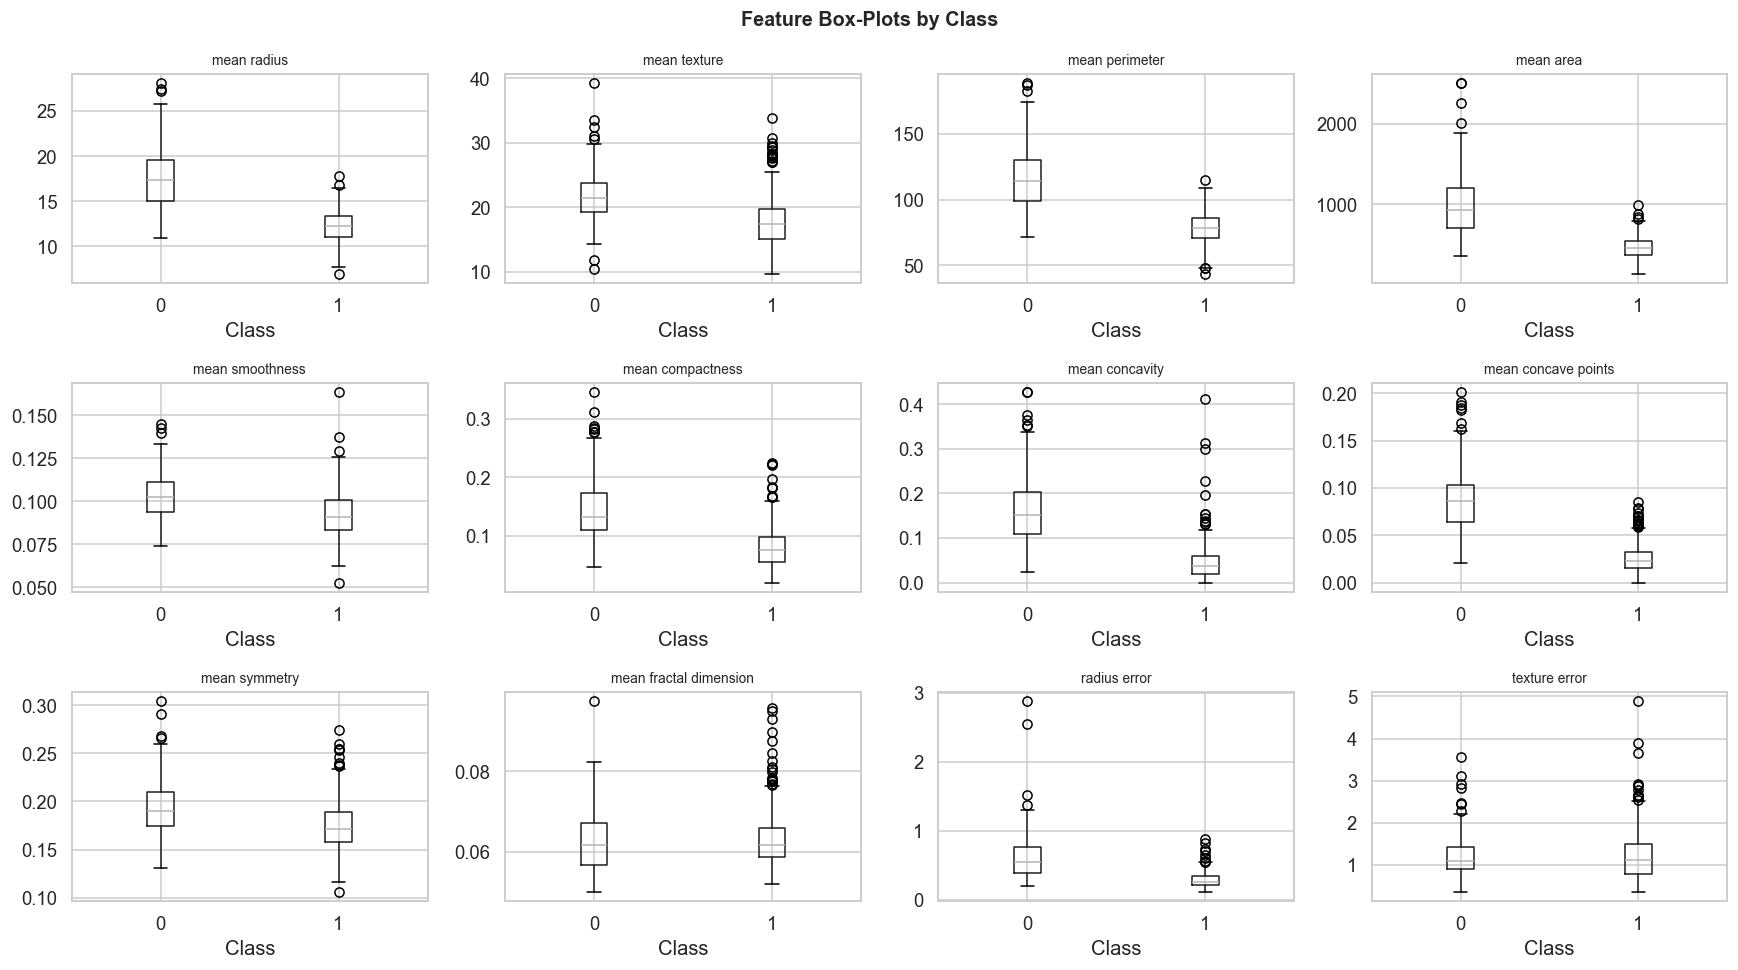

In [8]:
# ── 2.6 Box-plots: feature spread by class ───────────────────────────────────
top_features = numeric_cols[:12]
n_cols = 4
n_rows = int(np.ceil(len(top_features) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(top_features):
    df.boxplot(column=col, by=TARGET_COL, ax=axes[i])
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xlabel("Class")

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Feature Box-Plots by Class", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


## 3. Data Cleaning & Preprocessing

In [9]:
# ── 3.1 Separate features and target ────────────────────────────────────────
X = df.drop(columns=[TARGET_COL]).copy()
y = df[TARGET_COL].copy()

print(f"Features shape : {X.shape}")
print(f"Target shape   : {y.shape}")


Features shape : (569, 30)
Target shape   : (569,)


In [10]:
# ── 3.2 Handle missing values ───────────────────────────────────────────────
from sklearn.impute import SimpleImputer

# Numeric: median imputation
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()

if X[num_cols].isnull().sum().sum() > 0:
    imputer = SimpleImputer(strategy="median")
    X[num_cols] = imputer.fit_transform(X[num_cols])
    print("✓  Numeric missing values imputed with median.")

# Categorical: most-frequent imputation + label encoding
if cat_cols:
    from sklearn.preprocessing import LabelEncoder
    cat_imputer = SimpleImputer(strategy="most_frequent")
    X[cat_cols] = cat_imputer.fit_transform(X[cat_cols])
    le = LabelEncoder()
    for col in cat_cols:
        X[col] = le.fit_transform(X[col].astype(str))
    print(f"✓  Encoded {len(cat_cols)} categorical column(s).")

print(f"Missing values after cleaning: {X.isnull().sum().sum()}")


Missing values after cleaning: 0


In [11]:
# ── 3.3 Train / test split ──────────────────────────────────────────────────
TEST_SIZE = 0.20

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

print(f"Train set : {X_train.shape[0]} samples")
print(f"Test  set : {X_test.shape[0]} samples")
print(f"Train class balance: {dict(y_train.value_counts().sort_index())}")
print(f"Test  class balance: {dict(y_test.value_counts().sort_index())}")


Train set : 455 samples
Test  set : 114 samples
Train class balance: {0: np.int64(170), 1: np.int64(285)}
Test  class balance: {0: np.int64(42), 1: np.int64(72)}


In [12]:
# ── 3.4 Feature scaling ──────────────────────────────────────────────────────
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test), columns=X_test.columns, index=X_test.index
)
print("✓  Features standardised (zero mean, unit variance).")


✓  Features standardised (zero mean, unit variance).


## 4. Feature Engineering

Top 15 features by ANOVA F-score:
             Feature    F-score       p-value
worst concave points 795.223341 9.269318e-102
     worst perimeter 719.598823  1.327313e-95
 mean concave points 703.364031  3.135578e-94
        worst radius 687.430367  7.296427e-93
      mean perimeter 565.485755  1.011815e-81
          worst area 541.713694  2.150031e-79
         mean radius 523.613907  1.387363e-77
           mean area 469.516453  5.741182e-72
      mean concavity 416.374874  4.058059e-66
     worst concavity 365.747389  3.351548e-60
    mean compactness 269.466042  7.418408e-48
   worst compactness 257.926057  2.885121e-46
          area error 214.858763  4.296371e-40
        radius error 212.499767  9.611165e-40
     perimeter error 198.422440  1.247305e-37


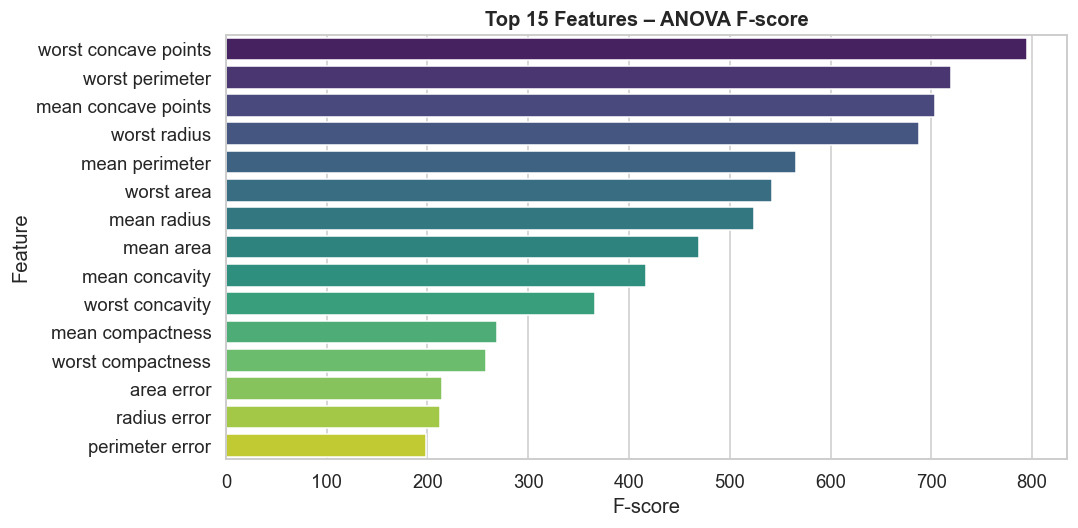

In [13]:
# ── 4.1 Univariate feature selection (SelectKBest) ──────────────────────────
K_BEST = min(15, X_train_scaled.shape[1])

selector = SelectKBest(score_func=f_classif, k=K_BEST)
selector.fit(X_train_scaled, y_train)

feature_scores = pd.DataFrame({
    "Feature"  : X_train_scaled.columns,
    "F-score"  : selector.scores_,
    "p-value"  : selector.pvalues_,
}).sort_values("F-score", ascending=False)

print(f"Top {K_BEST} features by ANOVA F-score:")
print(feature_scores.head(K_BEST).to_string(index=False))

plt.figure(figsize=(10, 5))
top_k = feature_scores.head(K_BEST)
sns.barplot(data=top_k, x="F-score", y="Feature", palette="viridis")
plt.title(f"Top {K_BEST} Features – ANOVA F-score", fontweight="bold")
plt.tight_layout()
plt.show()


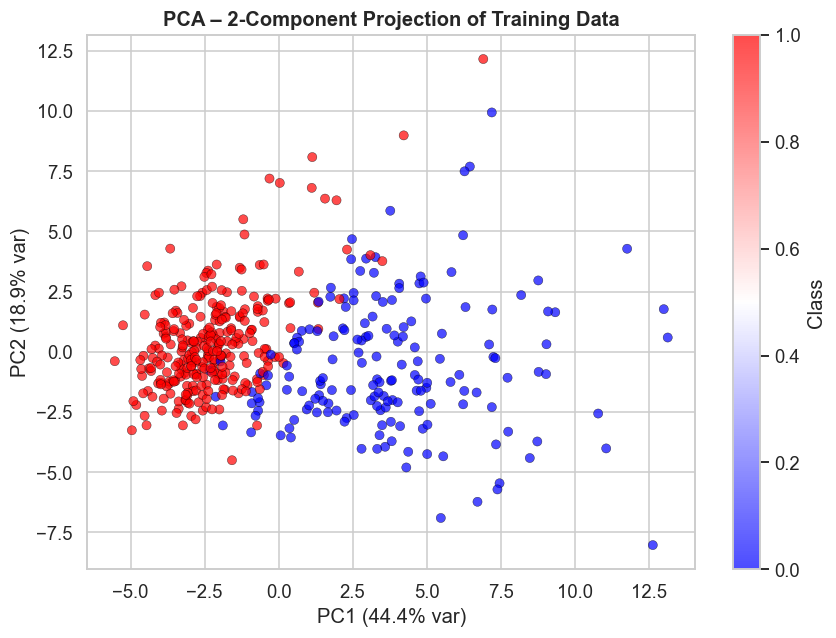

Components needed to explain 95% variance: 10


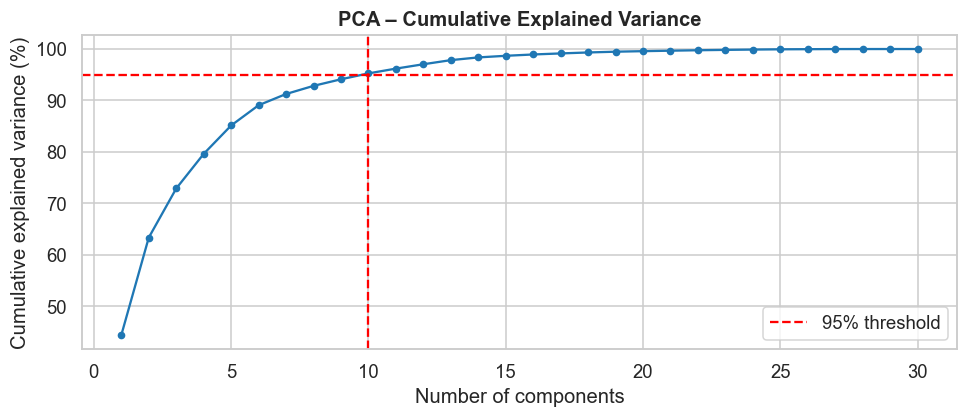

In [14]:
# ── 4.2 PCA – 2D visualisation of class separability ───────────────────────
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_train_scaled)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1],
                      c=y_train, cmap="bwr", alpha=0.7, edgecolors="k", linewidths=0.3)
plt.colorbar(scatter, label="Class")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)")
plt.title("PCA – 2-Component Projection of Training Data", fontweight="bold")
plt.tight_layout()
plt.show()

# Explained variance by components
pca_full = PCA(random_state=RANDOM_STATE).fit(X_train_scaled)
cumvar = np.cumsum(pca_full.explained_variance_ratio_)
n_95 = np.searchsorted(cumvar, 0.95) + 1
print(f"Components needed to explain 95% variance: {n_95}")

plt.figure(figsize=(9, 4))
plt.plot(range(1, len(cumvar) + 1), cumvar * 100, marker="o", markersize=4)
plt.axhline(95, color="red", linestyle="--", label="95% threshold")
plt.axvline(n_95, color="red", linestyle="--")
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance (%)")
plt.title("PCA – Cumulative Explained Variance", fontweight="bold")
plt.legend()
plt.tight_layout()
plt.show()


## 5. Define 13 Classifiers

In [15]:
MODELS = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000, random_state=RANDOM_STATE, class_weight="balanced"),

    "Decision Tree": DecisionTreeClassifier(
        random_state=RANDOM_STATE, class_weight="balanced"),

    "Random Forest": RandomForestClassifier(
        n_estimators=200, random_state=RANDOM_STATE,
        n_jobs=-1, class_weight="balanced"),

    "Extra Trees": ExtraTreesClassifier(
        n_estimators=200, random_state=RANDOM_STATE,
        n_jobs=-1, class_weight="balanced"),

    "Bagging": BaggingClassifier(
        n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=200, random_state=RANDOM_STATE),

    "AdaBoost": AdaBoostClassifier(
        n_estimators=200, random_state=RANDOM_STATE),

    "XGBoost": XGBClassifier(
        n_estimators=200, random_state=RANDOM_STATE,
        eval_metric="logloss",
        n_jobs=-1, verbosity=0),

    "LightGBM": LGBMClassifier(
        n_estimators=200, random_state=RANDOM_STATE,
        n_jobs=-1, verbose=-1),

    "SVM": SVC(
        kernel="rbf", probability=True,
        random_state=RANDOM_STATE, class_weight="balanced"),

    "KNN": KNeighborsClassifier(n_neighbors=7, n_jobs=-1),

    "Naive Bayes": GaussianNB(),

    "MLP Neural Network": MLPClassifier(
        hidden_layer_sizes=(128, 64), max_iter=500,
        random_state=RANDOM_STATE, early_stopping=True),
}

print(f"✓  {len(MODELS)} classifiers defined.")


✓  13 classifiers defined.


## 6. Cross-Validated Baseline Evaluation

In [16]:
CV_FOLDS = 5
SCORING   = ["accuracy", "precision", "recall", "f1", "roc_auc"]
skf = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

cv_results = {}

print(f"Running {CV_FOLDS}-fold stratified cross-validation on {len(MODELS)} models…")
for name, model in MODELS.items():
    scores = cross_validate(model, X_train_scaled, y_train,
                            cv=skf, scoring=SCORING, n_jobs=-1)
    cv_results[name] = {
        metric: scores[f"test_{metric}"] for metric in SCORING
    }
    print(f"  [{name:25s}]  AUC={scores['test_roc_auc'].mean():.4f}  "
          f"F1={scores['test_f1'].mean():.4f}  "
          f"Acc={scores['test_accuracy'].mean():.4f}")

print("\n✓  Cross-validation complete.")


Running 5-fold stratified cross-validation on 13 models…
  [Logistic Regression      ]  AUC=0.9957  F1=0.9823  Acc=0.9780
  [Decision Tree            ]  AUC=0.9231  F1=0.9464  Acc=0.9319
  [Random Forest            ]  AUC=0.9925  F1=0.9700  Acc=0.9626
  [Extra Trees              ]  AUC=0.9941  F1=0.9807  Acc=0.9758
  [Bagging                  ]  AUC=0.9883  F1=0.9609  Acc=0.9516
  [Gradient Boosting        ]  AUC=0.9928  F1=0.9686  Acc=0.9604
  [AdaBoost                 ]  AUC=0.9960  F1=0.9826  Acc=0.9780
  [XGBoost                  ]  AUC=0.9935  F1=0.9737  Acc=0.9670
  [LightGBM                 ]  AUC=0.9938  F1=0.9757  Acc=0.9692
  [SVM                      ]  AUC=0.9964  F1=0.9788  Acc=0.9736
  [KNN                      ]  AUC=0.9879  F1=0.9689  Acc=0.9604
  [Naive Bayes              ]  AUC=0.9884  F1=0.9478  Acc=0.9341
  [MLP Neural Network       ]  AUC=0.9824  F1=0.9627  Acc=0.9516

✓  Cross-validation complete.


In [17]:
# ── 6.1 Summary table ────────────────────────────────────────────────────────
summary_rows = []
for name, scores in cv_results.items():
    row = {"Model": name}
    for metric in SCORING:
        row[metric.capitalize() + " mean"] = scores[metric].mean()
        row[metric.capitalize() + " std"]  = scores[metric].std()
    summary_rows.append(row)

cv_summary = pd.DataFrame(summary_rows).sort_values("Roc_auc mean", ascending=False)
cv_summary = cv_summary.reset_index(drop=True)

# Style the table
styled = cv_summary.style.background_gradient(
    cmap="YlGn", subset=[c for c in cv_summary.columns if "mean" in c]
).format({c: "{:.4f}" for c in cv_summary.columns if c != "Model"})
styled


,Model,Accuracy mean,Accuracy std,Precision mean,Precision std,Recall mean,Recall std,F1 mean,F1 std,Roc_auc mean,Roc_auc std
0,SVM,0.9736,0.0112,0.9825,0.0109,0.9754,0.0179,0.9788,0.0091,0.9964,0.0037
1,AdaBoost,0.9780,0.0184,0.9759,0.0175,0.9895,0.0140,0.9826,0.0146,0.9960,0.0031
2,Logistic Regression,0.9780,0.0139,0.9859,0.0071,0.9789,0.0205,0.9823,0.0113,0.9957,0.0049
3,Extra Trees,0.9758,0.0176,0.9758,0.0138,0.9860,0.0205,0.9807,0.0142,0.9941,0.0042
4,LightGBM,0.9692,0.0082,0.9658,0.0103,0.9860,0.0131,0.9757,0.0066,0.9938,0.0043
5,XGBoost,0.9670,0.0139,0.9724,0.0174,0.9754,0.0179,0.9737,0.0111,0.9935,0.0047
6,Gradient Boosting,0.9604,0.0164,0.9622,0.0160,0.9754,0.0179,0.9686,0.0130,0.9928,0.0051
7,Random Forest,0.9626,0.0164,0.9718,0.0086,0.9684,0.0233,0.9700,0.0135,0.9925,0.0048
8,Naive Bayes,0.9341,0.0287,0.9414,0.0257,0.9544,0.0238,0.9478,0.0228,0.9884,0.0075
9,Bagging,0.9516,0.0192,0.9723,0.0253,0.9509,0.0281,0.9609,0.0156,0.9883,0.0082


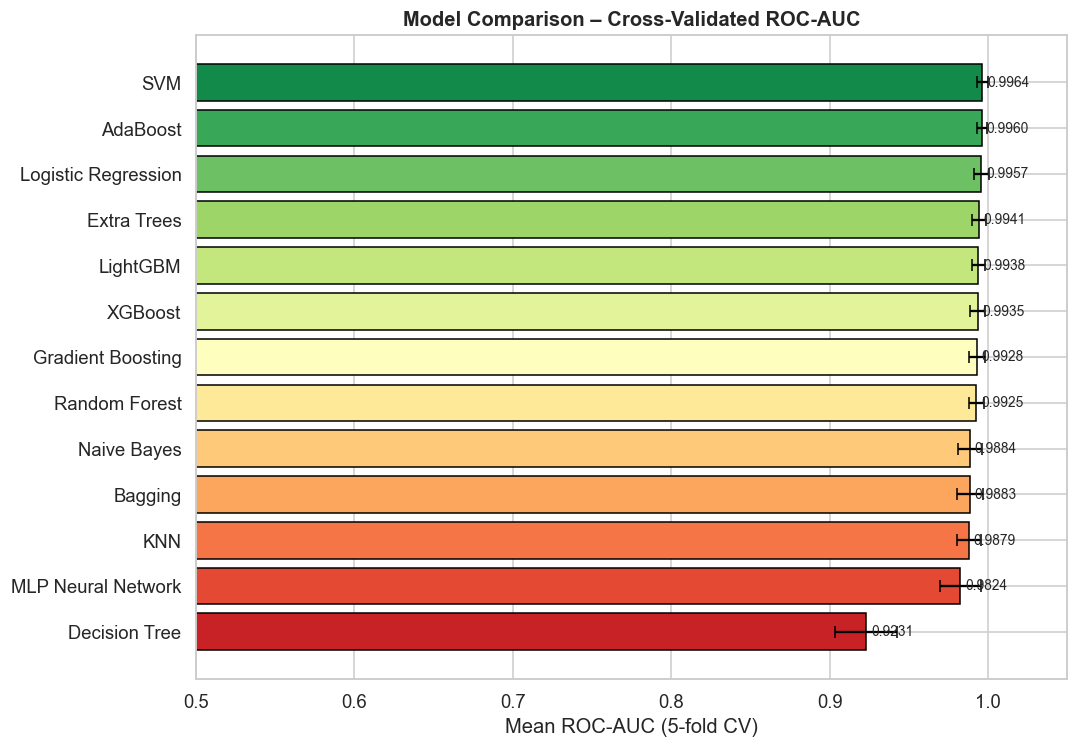

In [18]:
# ── 6.2 Cross-validation bar chart ──────────────────────────────────────────
metric_to_plot = "roc_auc"
means = cv_summary.sort_values(f"Roc_auc mean", ascending=True)

plt.figure(figsize=(10, 7))
colours = sns.color_palette("RdYlGn", len(means))
bars = plt.barh(means["Model"], means["Roc_auc mean"], color=colours, edgecolor="black")

errors = [cv_results[m]["roc_auc"].std() for m in means["Model"]]
plt.errorbar(means["Roc_auc mean"], range(len(means)),
             xerr=errors, fmt="none", color="black", capsize=4)

plt.xlabel("Mean ROC-AUC (5-fold CV)")
plt.title("Model Comparison – Cross-Validated ROC-AUC", fontweight="bold")
plt.xlim(0.5, 1.05)
for bar, val in zip(bars, means["Roc_auc mean"]):
    plt.text(val + 0.003, bar.get_y() + bar.get_height() / 2,
             f"{val:.4f}", va="center", fontsize=9)
plt.tight_layout()
plt.show()


## 7. Hyperparameter Tuning

### 7a. RandomizedSearchCV (scikit-learn)

In [19]:
# ── Define search spaces ─────────────────────────────────────────────────────
param_grids = {
    "Logistic Regression": {
        "C"       : [0.001, 0.01, 0.1, 1, 10, 100],
        "solver"  : ["lbfgs", "saga"],
        "penalty" : ["l2"],
    },
    "Random Forest": {
        "n_estimators"     : [100, 200, 300],
        "max_depth"        : [None, 5, 10, 20],
        "min_samples_split": [2, 5, 10],
        "max_features"     : ["sqrt", "log2"],
    },
    "XGBoost": {
        "n_estimators"  : [100, 200, 300],
        "learning_rate" : [0.01, 0.05, 0.1, 0.2],
        "max_depth"     : [3, 5, 7],
        "subsample"     : [0.7, 0.8, 1.0],
        "colsample_bytree": [0.7, 0.8, 1.0],
    },
    "LightGBM": {
        "n_estimators" : [100, 200, 300],
        "learning_rate": [0.01, 0.05, 0.1, 0.2],
        "num_leaves"   : [15, 31, 63],
        "subsample"    : [0.7, 0.8, 1.0],
    },
    "SVM": {
        "C"    : [0.1, 1, 10, 100],
        "gamma": ["scale", "auto", 0.001, 0.01],
    },
}

TUNE_MODELS = {k: MODELS[k] for k in param_grids}
N_ITER = 20   # increase for more thorough search

best_estimators = {}
tuning_results  = {}

print(f"Running RandomizedSearchCV ({N_ITER} iterations, {CV_FOLDS}-fold CV) …")
for name, model in TUNE_MODELS.items():
    search = RandomizedSearchCV(
        model, param_grids[name],
        n_iter=N_ITER, cv=skf, scoring="roc_auc",
        random_state=RANDOM_STATE, n_jobs=-1, refit=True,
    )
    search.fit(X_train_scaled, y_train)
    best_estimators[name] = search.best_estimator_
    tuning_results[name]  = {
        "best_params": search.best_params_,
        "best_cv_auc": search.best_score_,
    }
    print(f"  [{name:25s}]  Best CV AUC = {search.best_score_:.4f} | {search.best_params_}")

print("\n✓  Hyperparameter tuning complete.")


Running RandomizedSearchCV (20 iterations, 5-fold CV) …
  [Logistic Regression      ]  Best CV AUC = 0.9957 | {'solver': 'lbfgs', 'penalty': 'l2', 'C': 1}
  [Random Forest            ]  Best CV AUC = 0.9925 | {'n_estimators': 200, 'min_samples_split': 2, 'max_features': 'log2', 'max_depth': None}
  [XGBoost                  ]  Best CV AUC = 0.9943 | {'subsample': 0.7, 'n_estimators': 300, 'max_depth': 7, 'learning_rate': 0.1, 'colsample_bytree': 0.8}
  [LightGBM                 ]  Best CV AUC = 0.9946 | {'subsample': 1.0, 'num_leaves': 31, 'n_estimators': 200, 'learning_rate': 0.2}
  [SVM                      ]  Best CV AUC = 0.9964 | {'gamma': 'scale', 'C': 1}

✓  Hyperparameter tuning complete.


### 7b. Optuna – Bayesian Optimisation (Random Forest example)


Optuna best ROC-AUC  : 0.9917
Optuna best params   : {'n_estimators': 400, 'max_depth': 20, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2'}


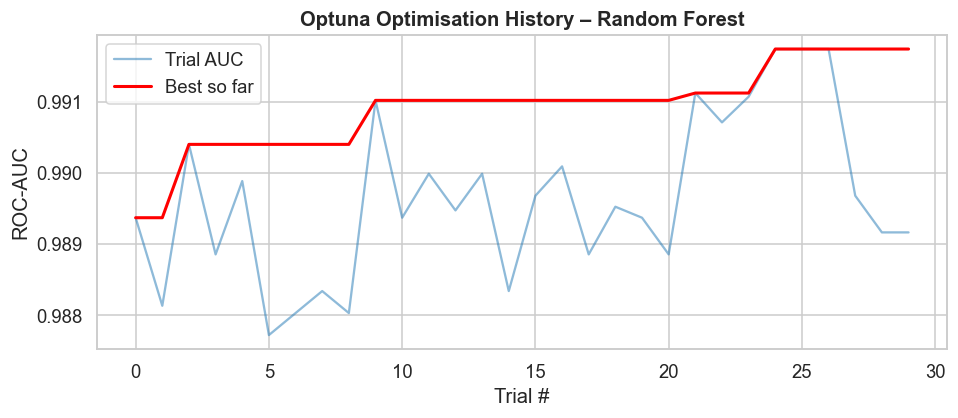

In [20]:
def objective_rf(trial):
    params = {
        "n_estimators"     : trial.suggest_int("n_estimators", 50, 400),
        "max_depth"        : trial.suggest_int("max_depth", 3, 20),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf" : trial.suggest_int("min_samples_leaf", 1, 10),
        "max_features"     : trial.suggest_categorical("max_features", ["sqrt", "log2"]),
    }
    model = RandomForestClassifier(
        **params, class_weight="balanced",
        random_state=RANDOM_STATE, n_jobs=-1
    )
    scores = cross_val_score(model, X_train_scaled, y_train,
                             cv=skf, scoring="roc_auc", n_jobs=-1)
    return scores.mean()

study = optuna.create_study(direction="maximize",
                            sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study.optimize(objective_rf, n_trials=30, show_progress_bar=False)

print(f"\nOptuna best ROC-AUC  : {study.best_value:.4f}")
print(f"Optuna best params   : {study.best_params}")

# Visualise optimisation history (using matplotlib)
trial_values = [t.value for t in study.trials]
best_so_far  = np.maximum.accumulate(trial_values)

plt.figure(figsize=(9, 4))
plt.plot(trial_values, alpha=0.5, label="Trial AUC")
plt.plot(best_so_far,  color="red", linewidth=2, label="Best so far")
plt.xlabel("Trial #")
plt.ylabel("ROC-AUC")
plt.title("Optuna Optimisation History – Random Forest", fontweight="bold")
plt.legend()
plt.tight_layout()
plt.show()

# Add the Optuna-tuned RF to best_estimators
optuna_rf = RandomForestClassifier(
    **study.best_params, class_weight="balanced",
    random_state=RANDOM_STATE, n_jobs=-1
)
best_estimators["Random Forest"] = optuna_rf.fit(X_train_scaled, y_train)


## 8. Final Test-Set Evaluation

In [21]:
# ── Collect all final models (tuned where available, default otherwise) ──────
final_models = {}
for name, model in MODELS.items():
    if name in best_estimators:
        final_models[name] = best_estimators[name]
    else:
        final_models[name] = model

# ── Fit every model on the full training set ──────────────────────────────────
fitted_models = {}
for name, model in final_models.items():
    fitted_models[name] = model.fit(X_train_scaled, y_train)

print("✓  All models fitted on training set.")


✓  All models fitted on training set.


In [22]:
# ── Compute test-set metrics ─────────────────────────────────────────────────
test_results = []

for name, model in fitted_models.items():
    y_pred  = model.predict(X_test_scaled)
    y_proba = (model.predict_proba(X_test_scaled)[:, 1]
               if hasattr(model, "predict_proba") else
               model.decision_function(X_test_scaled))

    test_results.append({
        "Model"    : name,
        "Accuracy" : accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall"   : recall_score(y_test, y_pred, zero_division=0),
        "F1"       : f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC"  : roc_auc_score(y_test, y_proba),
    })

test_df = pd.DataFrame(test_results).sort_values("ROC-AUC", ascending=False).reset_index(drop=True)

test_df.style.background_gradient(
    cmap="YlGn", subset=["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]
).format({c: "{:.4f}" for c in ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]})


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.9561,0.9855,0.9444,0.9645,0.9954
1,XGBoost,0.9561,0.9467,0.9861,0.9660,0.9947
2,SVM,0.9649,0.9857,0.9583,0.9718,0.9940
3,Random Forest,0.9474,0.9583,0.9583,0.9583,0.9934
4,Extra Trees,0.9561,0.9589,0.9722,0.9655,0.9934
5,Bagging,0.9386,0.9452,0.9583,0.9517,0.9927
6,MLP Neural Network,0.9561,0.9589,0.9722,0.9655,0.9921
7,LightGBM,0.9474,0.9459,0.9722,0.9589,0.9901
8,Gradient Boosting,0.9561,0.9467,0.9861,0.9660,0.9897
9,KNN,0.9737,0.9600,1.0000,0.9796,0.9884


## 9. Visualisations

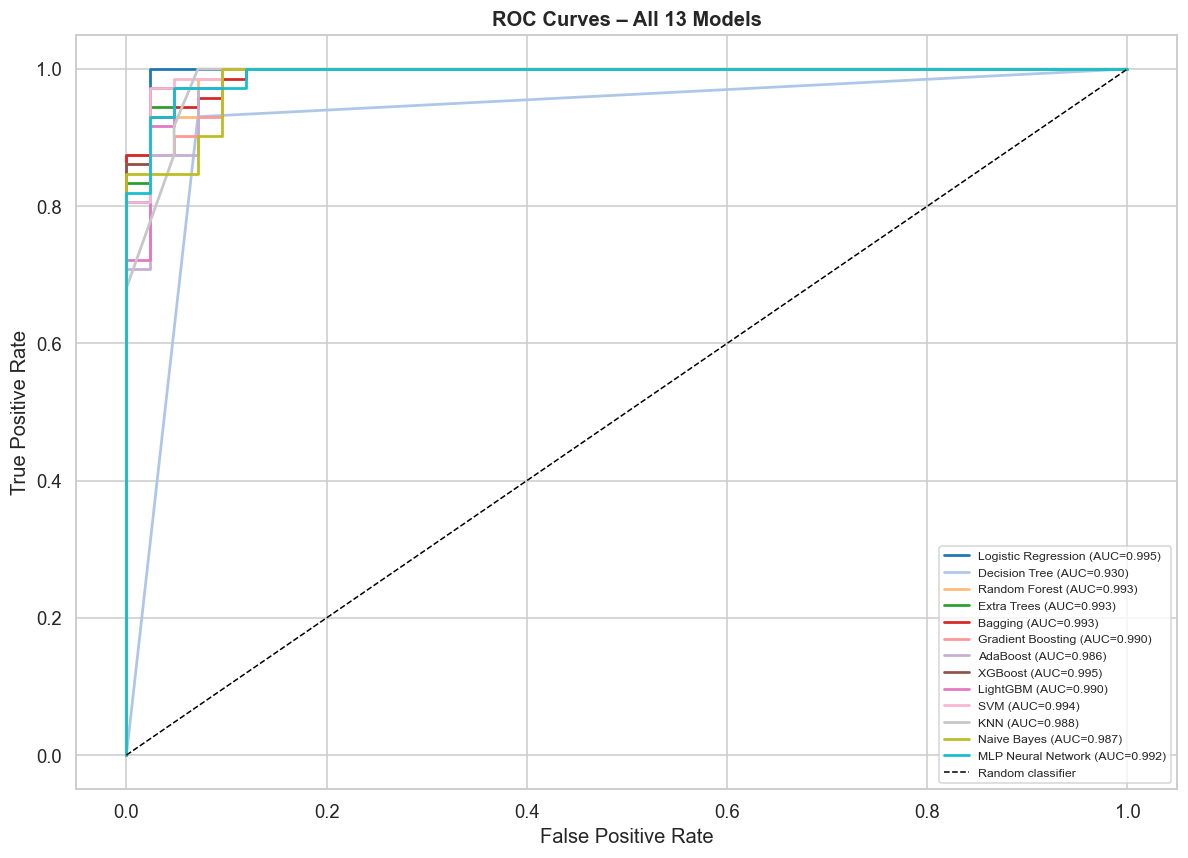

In [23]:
# ── 9.1 ROC Curves – all 13 models ──────────────────────────────────────────
plt.figure(figsize=(11, 8))
cmap = plt.get_cmap("tab20")

for i, (name, model) in enumerate(fitted_models.items()):
    y_proba = (model.predict_proba(X_test_scaled)[:, 1]
               if hasattr(model, "predict_proba") else
               model.decision_function(X_test_scaled))
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc_val = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=1.8, color=cmap(i / len(fitted_models)),
             label=f"{name} (AUC={auc_val:.3f})")

plt.plot([0, 1], [0, 1], "k--", lw=1, label="Random classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves – All 13 Models", fontweight="bold")
plt.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()


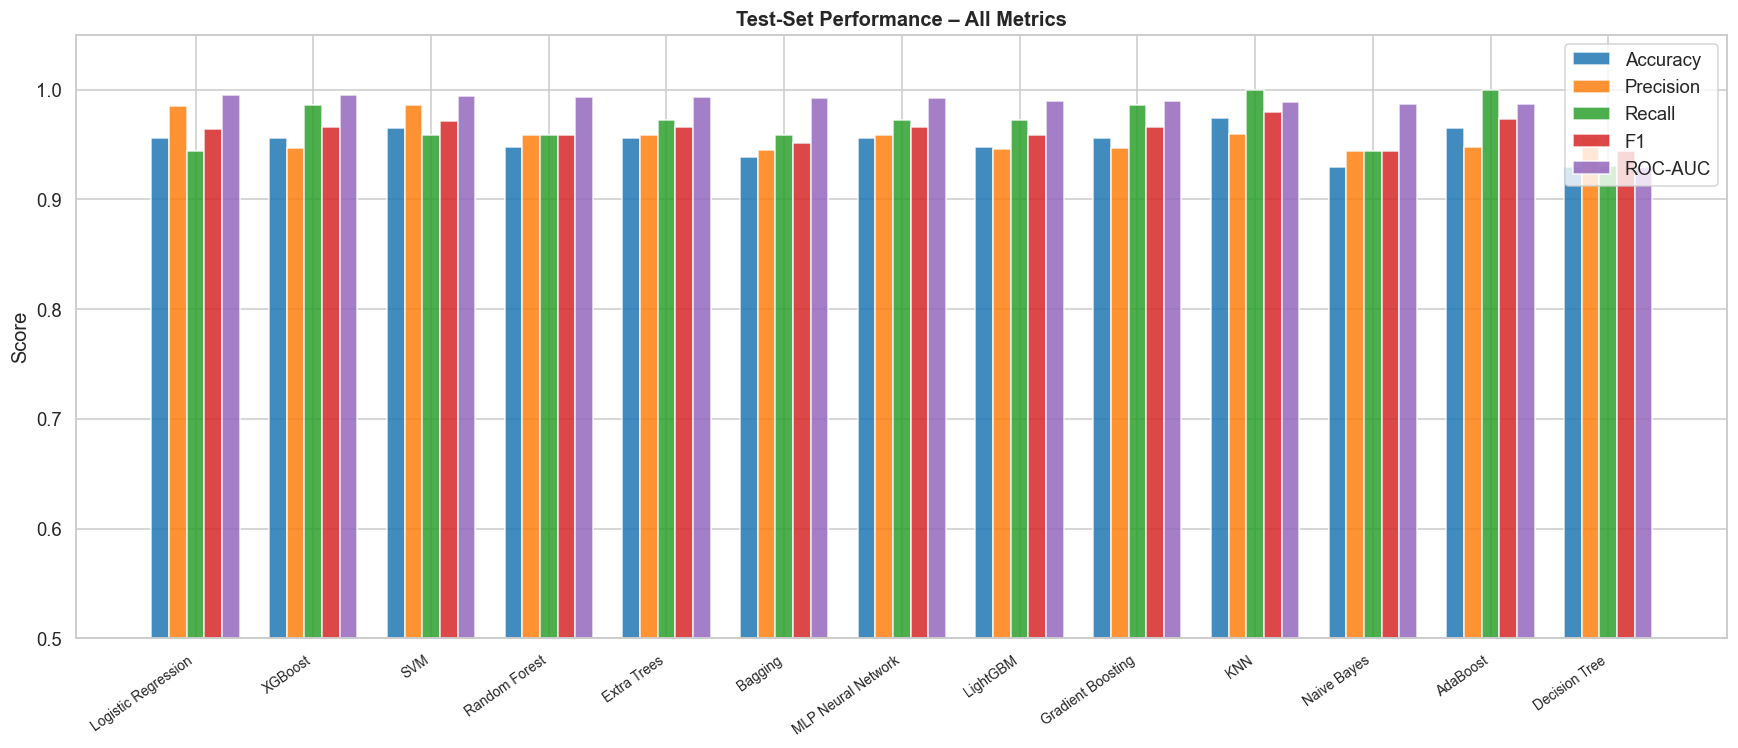

In [24]:
# ── 9.2 Performance bar chart (test set) ────────────────────────────────────
metrics = ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]
x = np.arange(len(test_df))
width = 0.15

fig, ax = plt.subplots(figsize=(16, 7))
for i, metric in enumerate(metrics):
    bars = ax.bar(x + i * width, test_df[metric], width,
                  label=metric, alpha=0.85)

ax.set_xticks(x + width * 2)
ax.set_xticklabels(test_df["Model"], rotation=35, ha="right", fontsize=9)
ax.set_ylabel("Score")
ax.set_ylim(0.5, 1.05)
ax.set_title("Test-Set Performance – All Metrics", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()


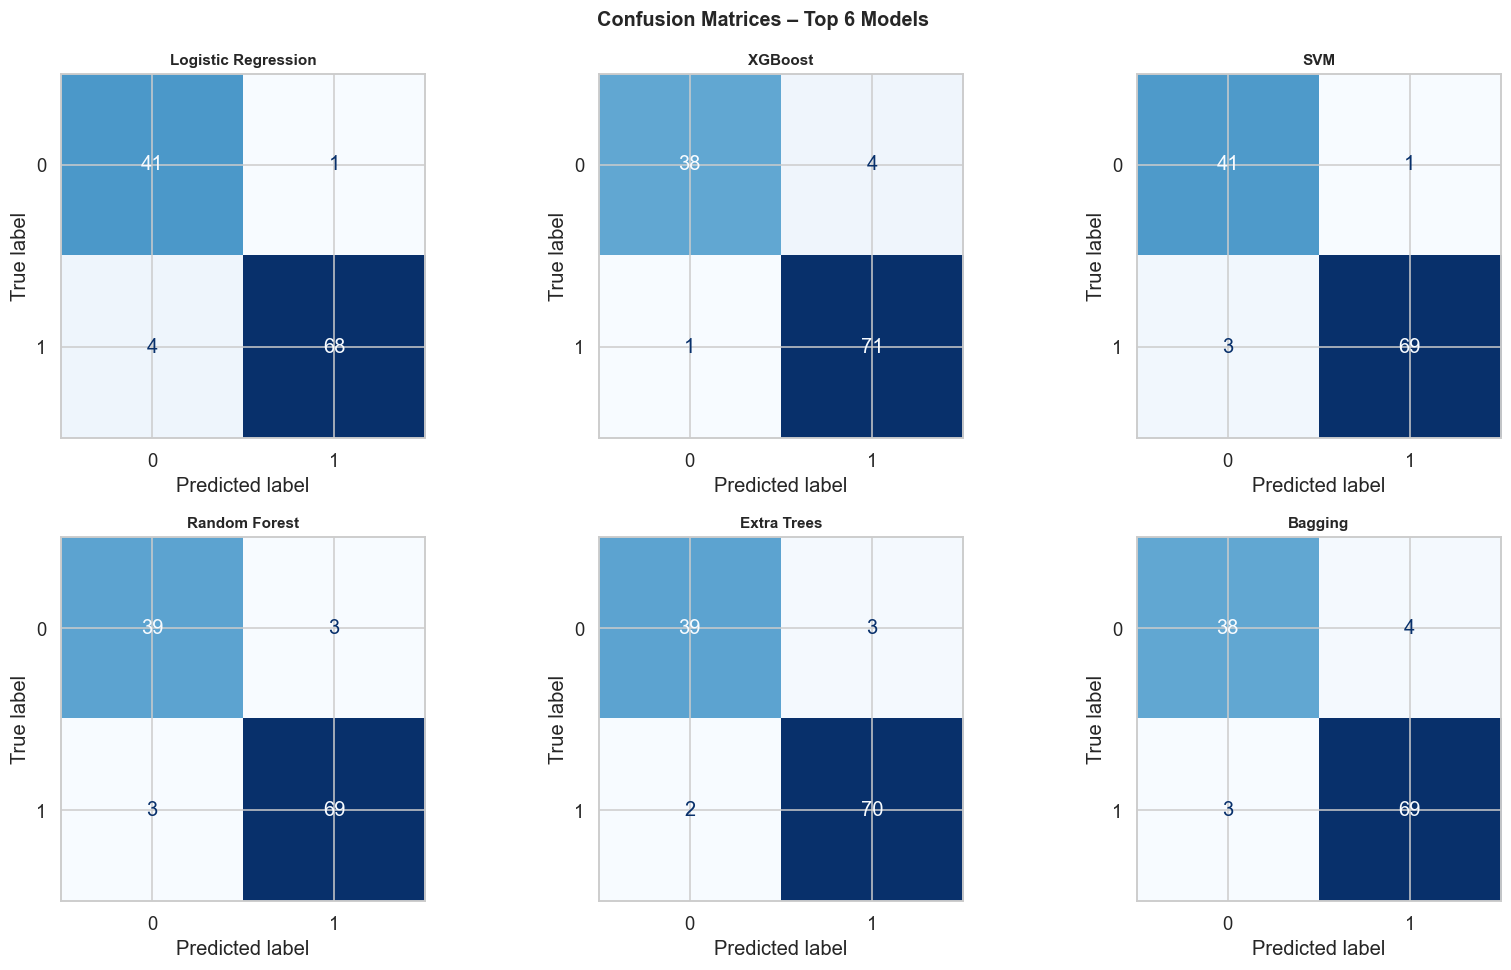

In [25]:
# ── 9.3 Confusion matrices – top 6 models by ROC-AUC ────────────────────────
top6_names = test_df["Model"].head(6).tolist()

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for ax, name in zip(axes, top6_names):
    model = fitted_models[name]
    y_pred = model.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm)
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(name, fontsize=10, fontweight="bold")

plt.suptitle("Confusion Matrices – Top 6 Models", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


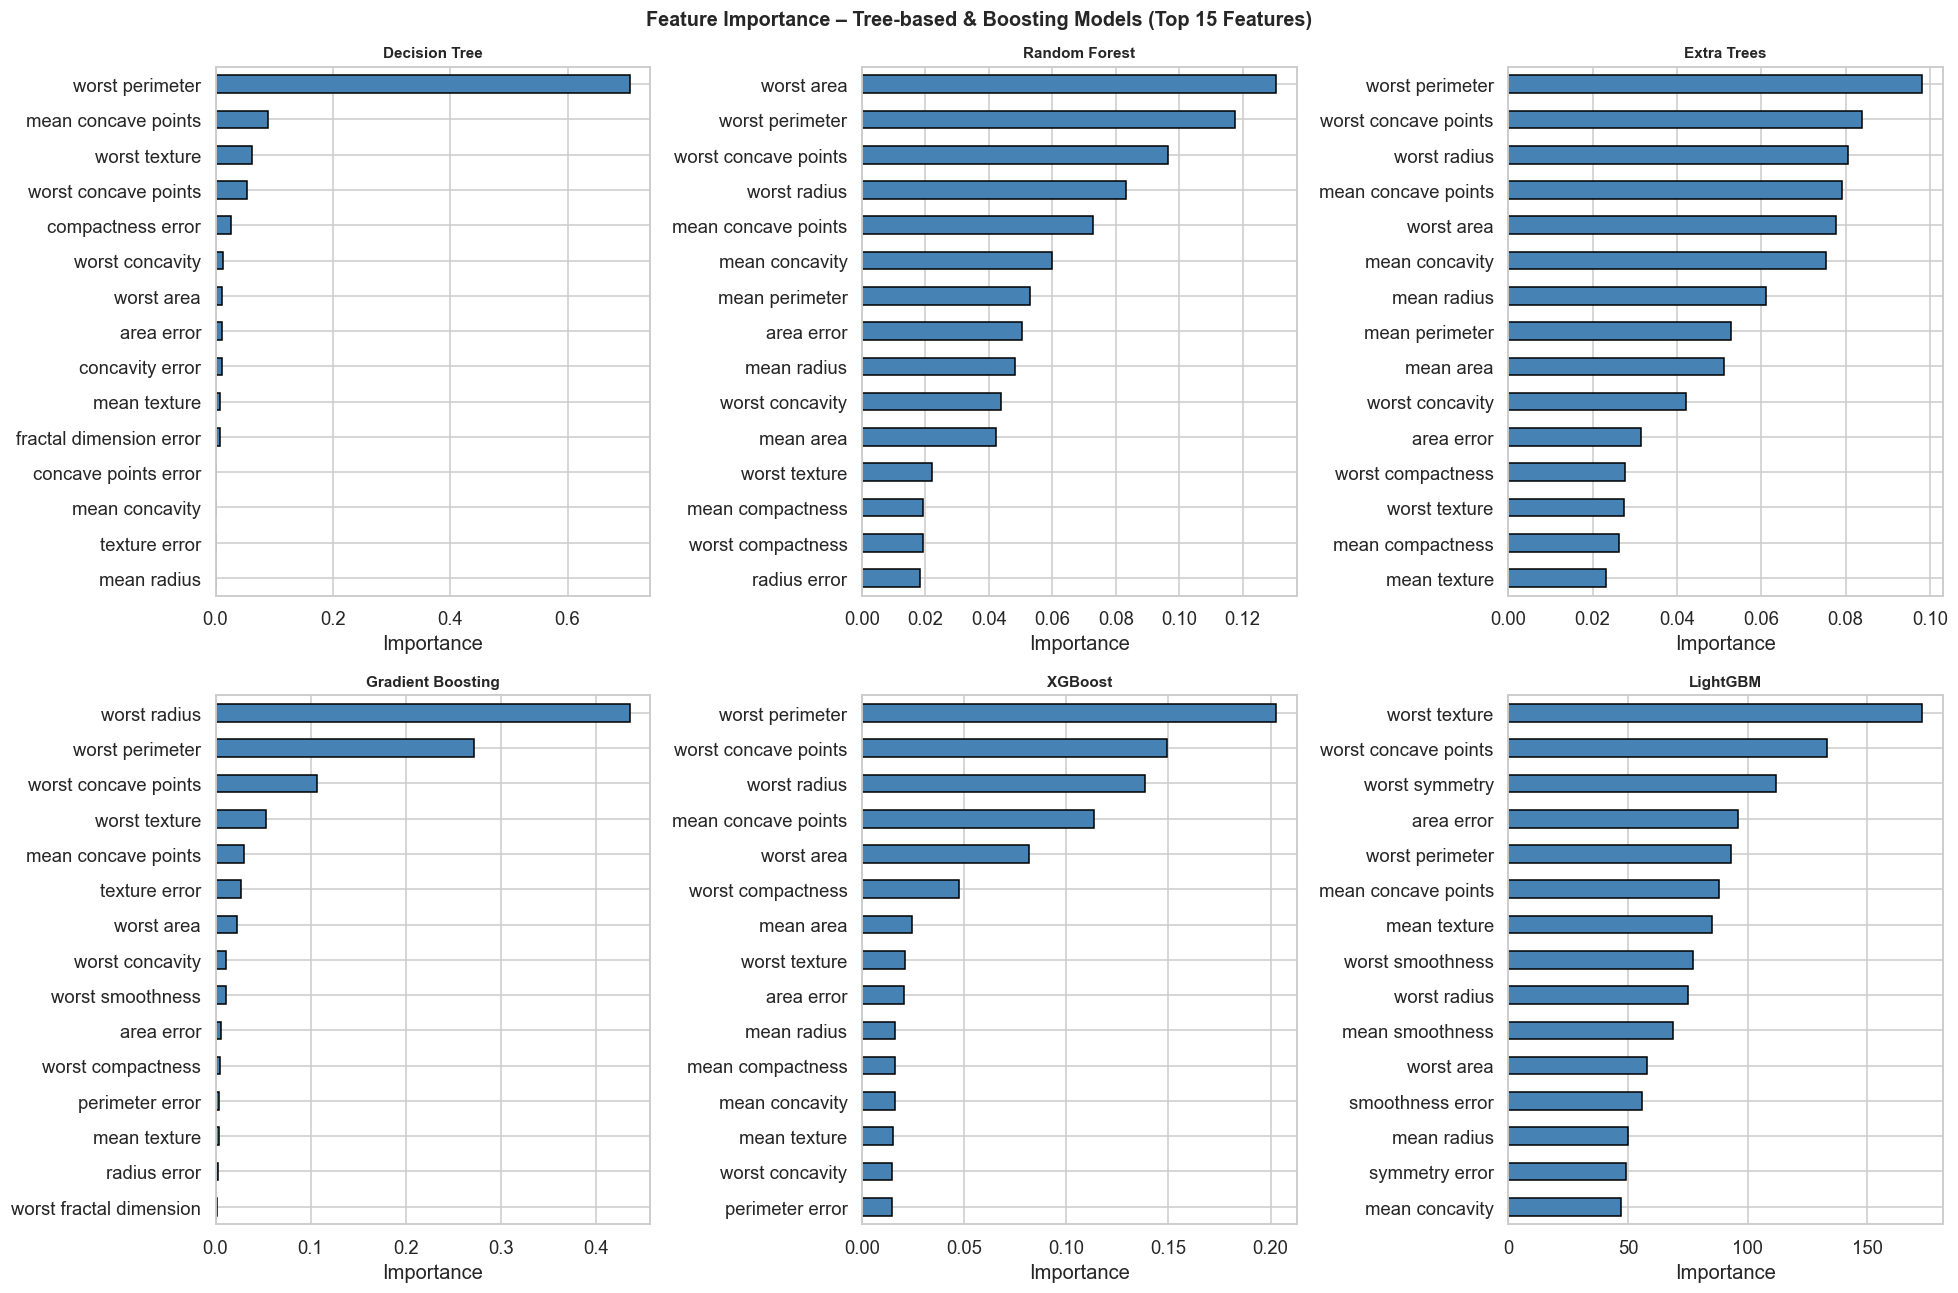

In [26]:
# ── 9.4 Feature importance ───────────────────────────────────────────────────
importance_models = {
    k: v for k, v in fitted_models.items()
    if k in ["Random Forest", "Extra Trees", "Gradient Boosting",
              "XGBoost", "LightGBM", "Decision Tree"]
}

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for ax, (name, model) in zip(axes, importance_models.items()):
    if hasattr(model, "feature_importances_"):
        importances = pd.Series(model.feature_importances_, index=X_train_scaled.columns)
    else:
        result = permutation_importance(model, X_test_scaled, y_test,
                                        n_repeats=10, random_state=RANDOM_STATE)
        importances = pd.Series(result.importances_mean, index=X_test_scaled.columns)

    top = importances.nlargest(15).sort_values()
    top.plot(kind="barh", ax=ax, color="steelblue", edgecolor="black")
    ax.set_title(name, fontweight="bold", fontsize=10)
    ax.set_xlabel("Importance")

plt.suptitle("Feature Importance – Tree-based & Boosting Models (Top 15 Features)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


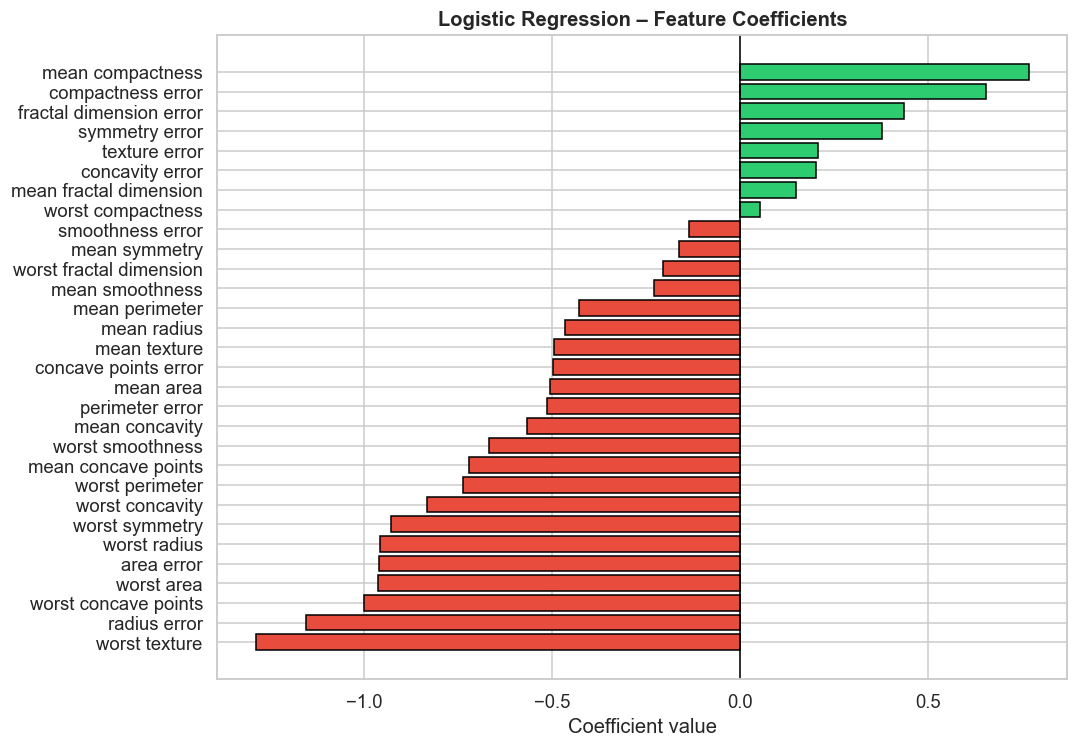

In [27]:
# ── 9.5 Logistic Regression coefficients ────────────────────────────────────
lr_model = fitted_models["Logistic Regression"]
coef_df = pd.DataFrame({
    "Feature"    : X_train_scaled.columns,
    "Coefficient": lr_model.coef_[0],
}).sort_values("Coefficient")

plt.figure(figsize=(10, 7))
colours = ["#e74c3c" if c < 0 else "#2ecc71" for c in coef_df["Coefficient"]]
plt.barh(coef_df["Feature"], coef_df["Coefficient"], color=colours, edgecolor="black")
plt.axvline(0, color="black", linewidth=1)
plt.xlabel("Coefficient value")
plt.title("Logistic Regression – Feature Coefficients", fontweight="bold")
plt.tight_layout()
plt.show()


## 10. Statistical Analysis

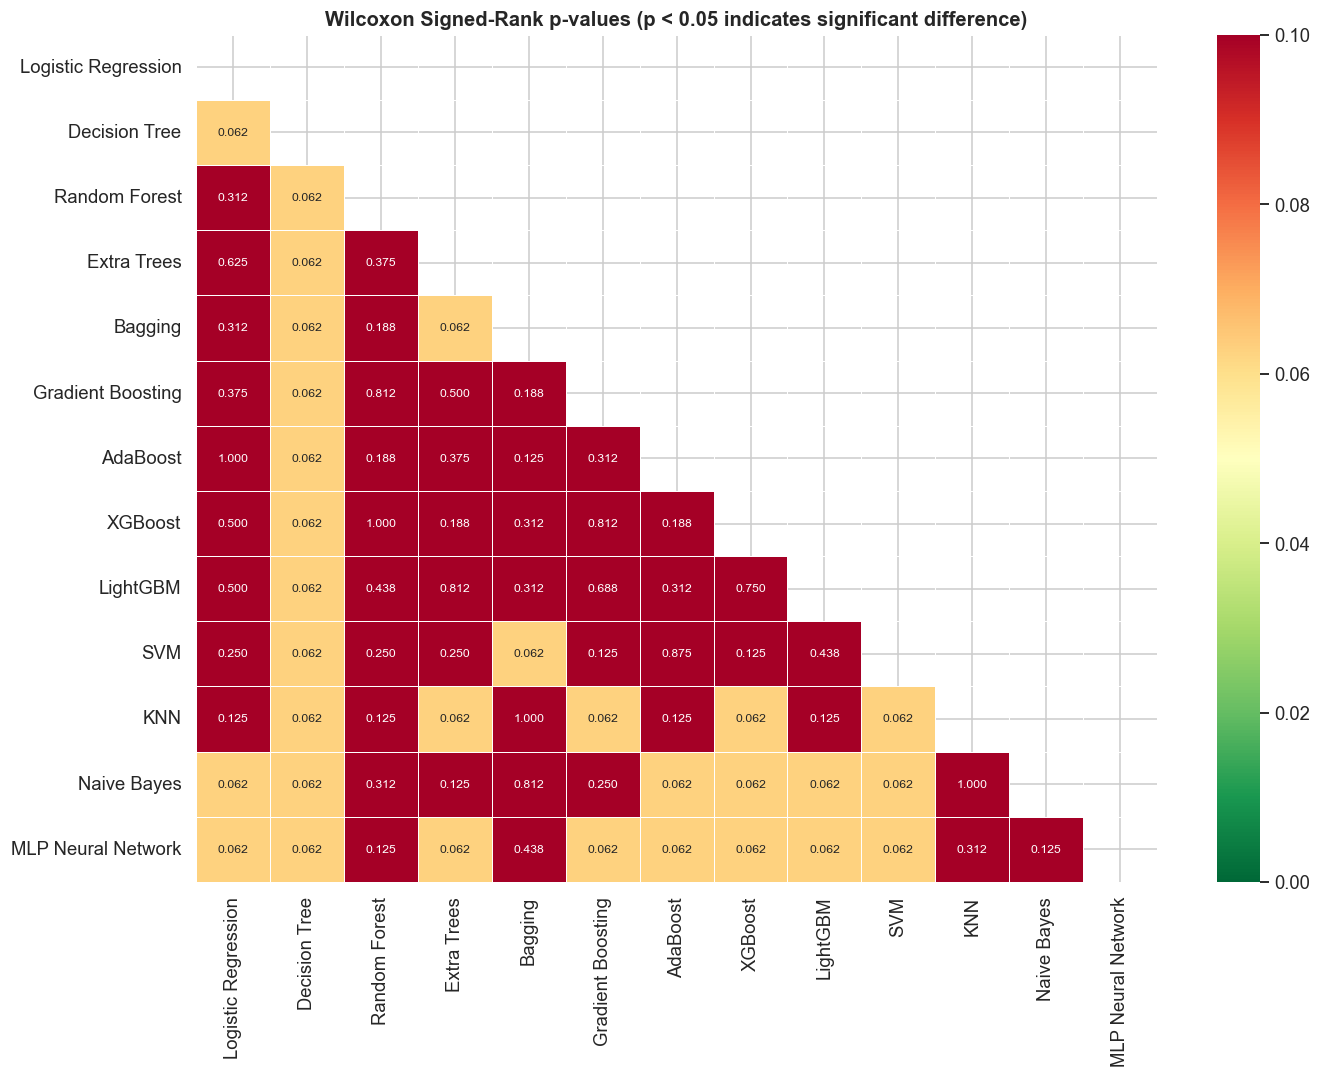


Significantly different pairs (p < 0.05): 0


In [28]:
# ── 10.1 Wilcoxon signed-rank test – pairwise model comparison ──────────────
#
# We compare each pair of models on their per-fold CV ROC-AUC scores.
# H0: the two models have the same median performance.

model_names = list(cv_results.keys())
n = len(model_names)
p_matrix = pd.DataFrame(np.ones((n, n)), index=model_names, columns=model_names)

for m1, m2 in combinations(model_names, 2):
    scores1 = cv_results[m1]["roc_auc"]
    scores2 = cv_results[m2]["roc_auc"]
    if np.all(scores1 == scores2):
        p_val = 1.0
    else:
        _, p_val = stats.wilcoxon(scores1, scores2, zero_method="zsplit")
    p_matrix.loc[m1, m2] = p_val
    p_matrix.loc[m2, m1] = p_val

mask = np.triu(np.ones_like(p_matrix, dtype=bool))
plt.figure(figsize=(13, 10))
sns.heatmap(p_matrix, mask=mask, annot=True, fmt=".3f",
            cmap="RdYlGn_r", vmin=0, vmax=0.1,
            linewidths=0.5, annot_kws={"size": 8})
plt.title("Wilcoxon Signed-Rank p-values (p < 0.05 indicates significant difference)",
          fontweight="bold")
plt.tight_layout()
plt.show()

significant_pairs = [
    (m1, m2, p_matrix.loc[m1, m2])
    for m1, m2 in combinations(model_names, 2)
    if p_matrix.loc[m1, m2] < 0.05
]
print(f"\nSignificantly different pairs (p < 0.05): {len(significant_pairs)}")
for m1, m2, p in sorted(significant_pairs, key=lambda x: x[2])[:10]:
    print(f"  {m1:25s} vs {m2:25s}  p={p:.4f}")


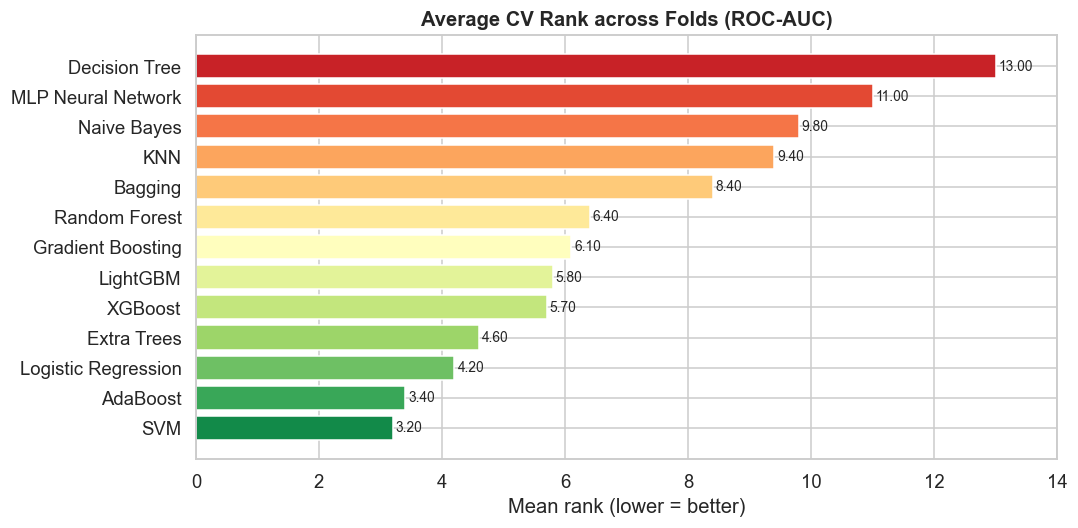

In [29]:
# ── 10.2 Critical difference – mean CV rank ──────────────────────────────────
#
# Rank models per fold (rank 1 = best) then average ranks.

fold_scores = pd.DataFrame(
    {name: cv_results[name]["roc_auc"] for name in model_names}
)
fold_ranks = fold_scores.rank(axis=1, ascending=False)
mean_ranks = fold_ranks.mean().sort_values()

plt.figure(figsize=(10, 5))
bars = plt.barh(mean_ranks.index, mean_ranks.values,
                color=sns.color_palette("RdYlGn_r", len(mean_ranks)))
plt.xlabel("Mean rank (lower = better)")
plt.title("Average CV Rank across Folds (ROC-AUC)", fontweight="bold")
for bar, val in zip(bars, mean_ranks.values):
    plt.text(val + 0.05, bar.get_y() + bar.get_height() / 2,
             f"{val:.2f}", va="center", fontsize=9)
plt.xlim(0, len(model_names) + 1)
plt.tight_layout()
plt.show()


In [30]:
# ── 10.3 Final summary ───────────────────────────────────────────────────────
best_model_name = test_df.iloc[0]["Model"]
best_auc        = test_df.iloc[0]["ROC-AUC"]

print("=" * 60)
print("          FINAL RESULTS SUMMARY")
print("=" * 60)
print(f"  Best model (test ROC-AUC) : {best_model_name}")
print(f"  Test ROC-AUC              : {best_auc:.4f}")
print(f"  Test F1                   : {test_df.iloc[0]['F1']:.4f}")
print(f"  Test Accuracy             : {test_df.iloc[0]['Accuracy']:.4f}")
print("=" * 60)
print("\nFull test-set leaderboard:")
print(test_df[["Model", "Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]]
      .to_string(index=False))


          FINAL RESULTS SUMMARY
  Best model (test ROC-AUC) : Logistic Regression
  Test ROC-AUC              : 0.9954
  Test F1                   : 0.9645
  Test Accuracy             : 0.9561

Full test-set leaderboard:
              Model  Accuracy  Precision   Recall       F1  ROC-AUC
Logistic Regression  0.956140   0.985507 0.944444 0.964539 0.995370
            XGBoost  0.956140   0.946667 0.986111 0.965986 0.994709
                SVM  0.964912   0.985714 0.958333 0.971831 0.994048
      Random Forest  0.947368   0.958333 0.958333 0.958333 0.993386
        Extra Trees  0.956140   0.958904 0.972222 0.965517 0.993386
            Bagging  0.938596   0.945205 0.958333 0.951724 0.992725
 MLP Neural Network  0.956140   0.958904 0.972222 0.965517 0.992063
           LightGBM  0.947368   0.945946 0.972222 0.958904 0.990079
  Gradient Boosting  0.956140   0.946667 0.986111 0.965986 0.989749
                KNN  0.973684   0.960000 1.000000 0.979592 0.988426
        Naive Bayes  0.929825  

## 11. Detailed Report – Best Model

=== Classification Report: Logistic Regression ===

              precision    recall  f1-score   support

           0       0.91      0.98      0.94        42
           1       0.99      0.94      0.96        72

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114

Optimal decision threshold (Youden's J) : 0.3132


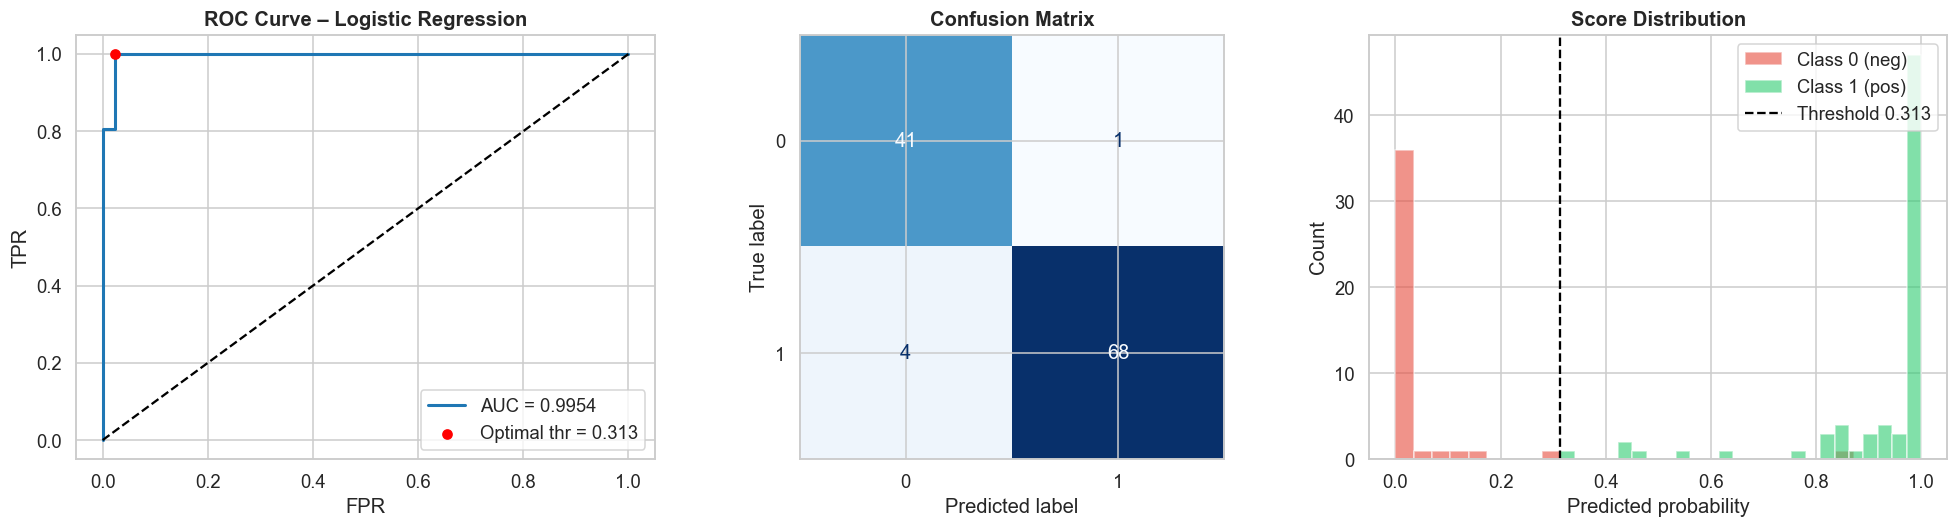

In [31]:
best_model = fitted_models[best_model_name]
y_pred_best  = best_model.predict(X_test_scaled)
y_proba_best = (best_model.predict_proba(X_test_scaled)[:, 1]
                if hasattr(best_model, "predict_proba") else
                best_model.decision_function(X_test_scaled))

print(f"=== Classification Report: {best_model_name} ===\n")
print(classification_report(y_test, y_pred_best))

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba_best)
roc_auc_val = auc(fpr, tpr)

# Optimal threshold (Youden's J)
youden_j = tpr - fpr
opt_idx   = np.argmax(youden_j)
opt_thr   = thresholds[opt_idx]
print(f"Optimal decision threshold (Youden's J) : {opt_thr:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ROC
axes[0].plot(fpr, tpr, lw=2, label=f"AUC = {roc_auc_val:.4f}")
axes[0].scatter(fpr[opt_idx], tpr[opt_idx], color="red", zorder=5,
                label=f"Optimal thr = {opt_thr:.3f}")
axes[0].plot([0, 1], [0, 1], "k--")
axes[0].set_xlabel("FPR"); axes[0].set_ylabel("TPR")
axes[0].set_title(f"ROC Curve – {best_model_name}", fontweight="bold")
axes[0].legend()

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_best)
ConfusionMatrixDisplay(cm).plot(ax=axes[1], colorbar=False, cmap="Blues")
axes[1].set_title("Confusion Matrix", fontweight="bold")

# Predicted probability distribution
axes[2].hist(y_proba_best[y_test == 0], bins=25, alpha=0.6,
             label="Class 0 (neg)", color="#e74c3c")
axes[2].hist(y_proba_best[y_test == 1], bins=25, alpha=0.6,
             label="Class 1 (pos)", color="#2ecc71")
axes[2].axvline(opt_thr, color="black", linestyle="--", label=f"Threshold {opt_thr:.3f}")
axes[2].set_xlabel("Predicted probability")
axes[2].set_ylabel("Count")
axes[2].set_title("Score Distribution", fontweight="bold")
axes[2].legend()

plt.tight_layout()
plt.show()


## 12. Save Results

In [32]:
import os, joblib

OUTPUT_DIR = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Save best model ────────────────────────────────────────────────────────
model_path = os.path.join(OUTPUT_DIR, "best_model.pkl")
joblib.dump(best_model, model_path)
print(f"✓  Best model saved → {model_path}")

# ── Save scaler ───────────────────────────────────────────────────────────
scaler_path = os.path.join(OUTPUT_DIR, "scaler.pkl")
joblib.dump(scaler, scaler_path)
print(f"✓  Scaler saved      → {scaler_path}")

# ── Save results CSV ──────────────────────────────────────────────────────
results_path = os.path.join(OUTPUT_DIR, "test_results.csv")
test_df.to_csv(results_path, index=False)
print(f"✓  Results saved     → {results_path}")

# ── Loading example ───────────────────────────────────────────────────────
print("\nExample – loading and using the saved model:")
print("  import joblib")
print(f"  model  = joblib.load('{model_path}')")
print(f"  scaler = joblib.load('{scaler_path}')")
print("  X_new_scaled = scaler.transform(X_new)")
print("  preds        = model.predict(X_new_scaled)")


✓  Best model saved → outputs\best_model.pkl
✓  Scaler saved      → outputs\scaler.pkl
✓  Results saved     → outputs\test_results.csv

Example – loading and using the saved model:
  import joblib
  model  = joblib.load('outputs\best_model.pkl')
  scaler = joblib.load('outputs\scaler.pkl')
  X_new_scaled = scaler.transform(X_new)
  preds        = model.predict(X_new_scaled)
